In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 한글깨짐 해결
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

## 실습 1. 정상 데이터의 평균·표준편차
### 목표
정상 데이터만 골라 중심인 평균과 산포인 표준편차를 구하기
### 단계
- 정답이 정상인 행만 골라내기
- 정상 데이터의 평균을 구해 중심 확인
- 정상 데이터의 표준편차를 구해 흩어짐 확인
### 예상 결과
정상 96개, 평균 약 0.1015, 표준편차 약 0.0184

In [7]:
# 실습1 코드
df = pd.read_csv('25_mimii_features.csv')
normal = df[df['label'] == 0]
# normal.head()

# normal.describe()
print('정상 개수:', len(normal)) # 정상 개수: 96
print('평균:', round(normal['rms'].mean(), 4)) # 평균: 0.1015
print('표준편차:', round(normal['rms'].std(), 4)) # 표준편차: 0.0184

정상 개수: 96
평균: 0.1015
표준편차: 0.0184


## 실습 2. 정상 범위 계산 (평균±3σ)
### 목표
정상 평균에 표준편차 세 배를 더하고 빼 정상으로 볼 범위를 정하기
### 단계
- 정상 데이터의 평균과 표준편차를 준비
- 평균에서 표준편차 세 배만큼 아래·위로 벌려 범위를 만들기
- 이 범위를 벗어난 값을 이상 후보로 보기
### 예상 결과
정상 범위 약 0.046~0.157, 이 밖이면 이상 후보


In [8]:
# 실습2 코드
m = normal['rms'].mean()
s = normal['rms'].std()

low = m - s * 3
high = m + s * 3

print('정상 범위:', round(low, 3), '~', round(high, 3)) # 정상 범위: 0.046 ~ 0.157

정상 범위: 0.046 ~ 0.157


### 실습 3. 분포 히스토그램·박스플롯 관찰
### 목표
히스토그램과 박스플롯으로 데이터 분포와 튀는 값을 관찰
### 단계
- 한 특징의 히스토그램을 그려 값이 몰린 위치 보기
- 같은 특징의 박스플롯을 그려 상자 밖 점 확인
- 정상은 몰리고 이상은 꼬리로 떨어짐을 관찰
### 예상 결과
정상은 낮은 값에 몰리고, 이상은 오른쪽 꼬리로 떨어져 나옴

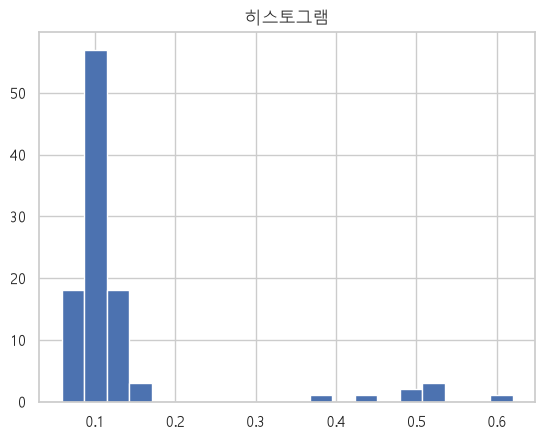

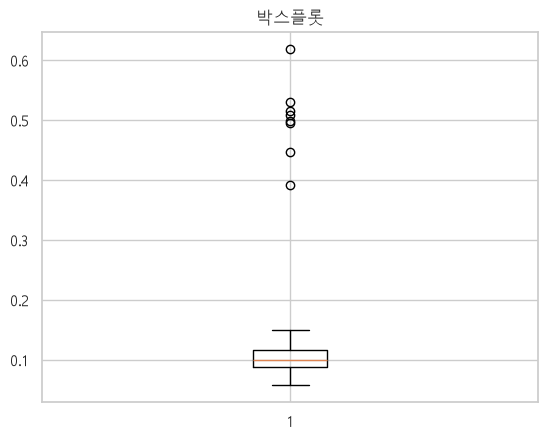

In [9]:
# 실습3 코드
plt.hist(df['rms'], bins=20)
plt.title('히스토그램')
plt.show()

plt.boxplot(df['rms'])
plt.title('박스플롯')
plt.show()

## 실습 4. 센서별 정상·이상 통계 비교
### 목표
특징마다 정상 그룹과 이상 그룹의 평균을 비교해 감별력을 보기
### 단계
· 정답이 이상인 행만 따로 골라내기
· 세 특징마다 정상 평균과 이상 평균을 나란히 출력
· 두 평균 차이가 큰 특징을 좋은 감별 특징으로 선별
### 예상 결과
세 특징 모두 이상 평균이 크게 높아 잘 갈림


In [10]:
# 실습4 코드
abnormal = df[df['label'] == 1]

for col in ['rms', 'spectral_centroid', 'zero_crossing_rate']:
    print(col, '정상:', round(normal[col].mean(), 3))
    print('이상:', round(abnormal[col].mean(), 3))
# rms 정상: 0.101
# 이상: 0.501
# spectral_centroid 정상: 1784.023
# 이상: 2871.663
# zero_crossing_rate 정상: 0.081
# 이상: 0.222

rms 정상: 0.101
이상: 0.501
spectral_centroid 정상: 1784.023
이상: 2871.663
zero_crossing_rate 정상: 0.081
이상: 0.222
